## Califonia Housing Data Set : Predicting the price of the house by Linear Regression
The California Housing dataset originates from the 1990 U.S. Census.It contains 20,640 observations across 8 numerical features describing demographic and geographic characteristics of California districts. The target variable is the median house value (in hundreds of thousands of dollars).
Features:

* MedInc – Median income in block group
* HouseAge – Median house age in block group
* AveRooms – Average number of rooms per household
* AveBedrms – Average number of bedrooms per household
* Population – Block group population
* AveOccup – Average household size
* Latitude – Block group latitude
* Longitude – Block group longitude
* Target:
   ##### MedHouseValue – Median house value 

In [1]:
## Reqired Libraries.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error,r2_score
## Import the data set 
df = pd.read_csv(r"C:\Users\ACER\ML\california_housing_price_prediction\data\row\housing.csv" )

print(f"Shape of the dataset : {df.shape}")

### Checking Null values , replace by mean

# print(f"\nNull Values : {df.isnull().sum()}")

df['total_bedrooms'] = df['total_bedrooms'].fillna(
    df['total_bedrooms'].median()
)
print(df.isnull().sum())


Shape of the dataset : (20640, 10)
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,536.838857,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,419.391878,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,297.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,643.250000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


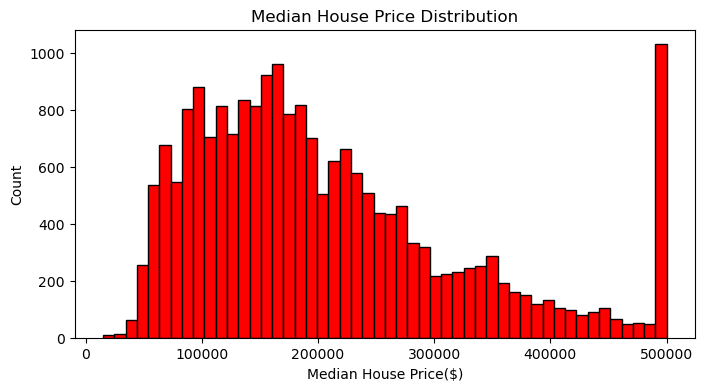

In [3]:
## House Price Distribution
plt.figure(figsize = (8,4))
plt.hist (df['median_house_value'], bins=50, color='red',edgecolor = 'black')
plt.title("Median House Price Distribution")
plt.xlabel("Median House Price($)")
plt.ylabel("Count")
plt.show()

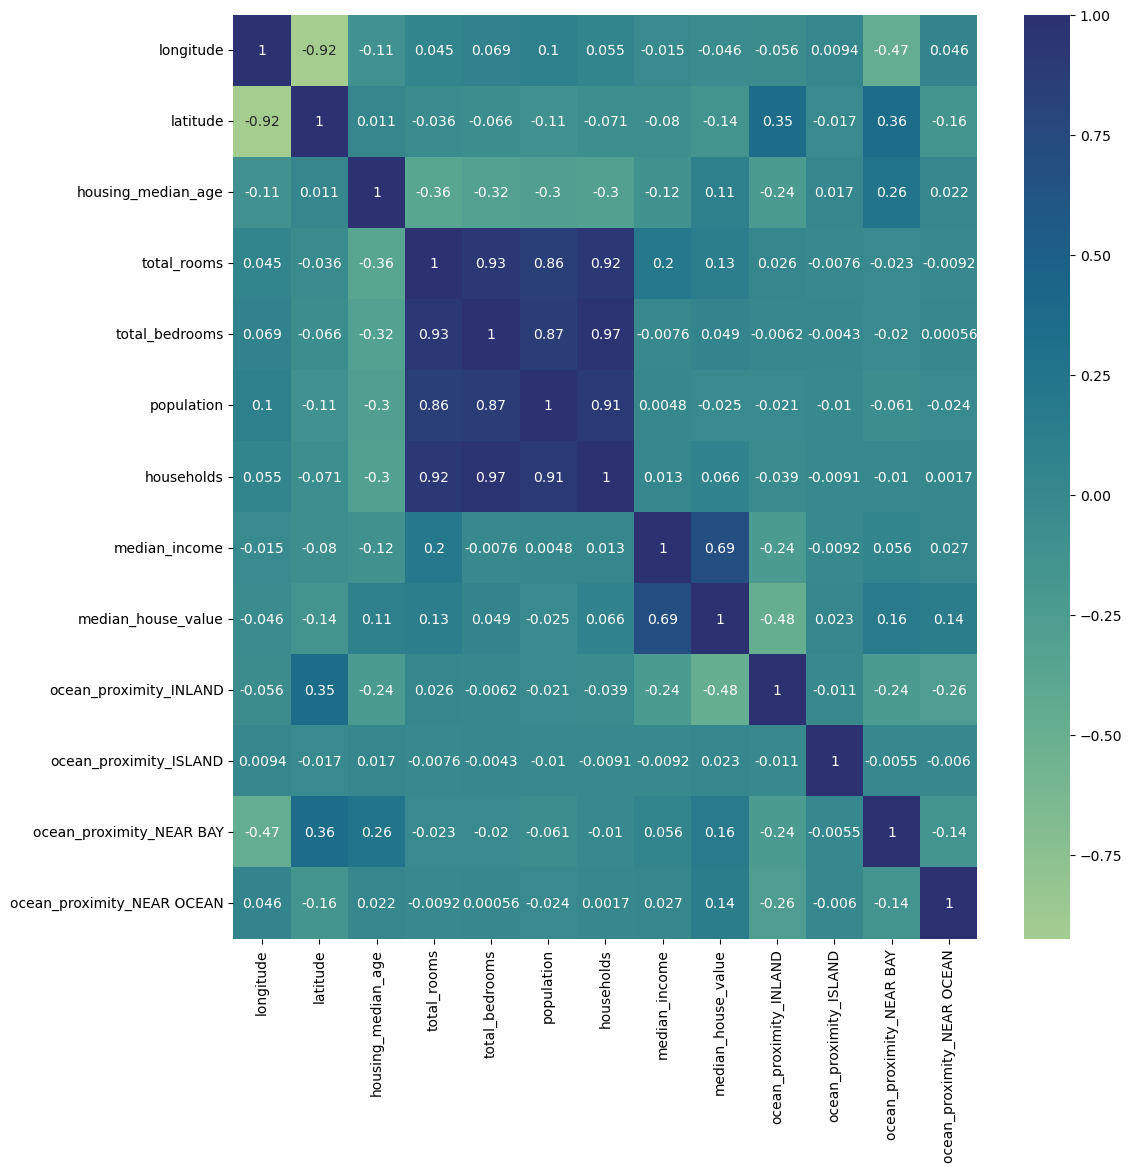

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-122.26,37.80,20.0,2373.0,779.0,1659.0,676.0,1.6929,115000.0,False,False,True,False
196,-122.22,37.77,52.0,391.0,128.0,520.0,138.0,1.6471,95000.0,False,False,True,False
197,-122.22,37.77,52.0,1137.0,301.0,866.0,259.0,2.5900,96400.0,False,False,True,False
198,-122.23,37.77,52.0,769.0,206.0,612.0,183.0,2.5700,72000.0,False,False,True,False


<Figure size 640x480 with 0 Axes>

In [4]:
## Correlation Heat map : Visualizes the Correlation
 ## 1. one_hot Encoding for proximity coloumn:
df_encoded = pd.get_dummies(
    df,
    columns  = ['ocean_proximity'],
    drop_first = True
)
corr_matrix = df_encoded.corr()
 ## 2. Coorelation heat map
plt.figure(figsize=(12,12))
sns.heatmap(corr_matrix,annot = True, cmap='crest')
plt.show()

plt.savefig("../images/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")
df_encoded.head(200)

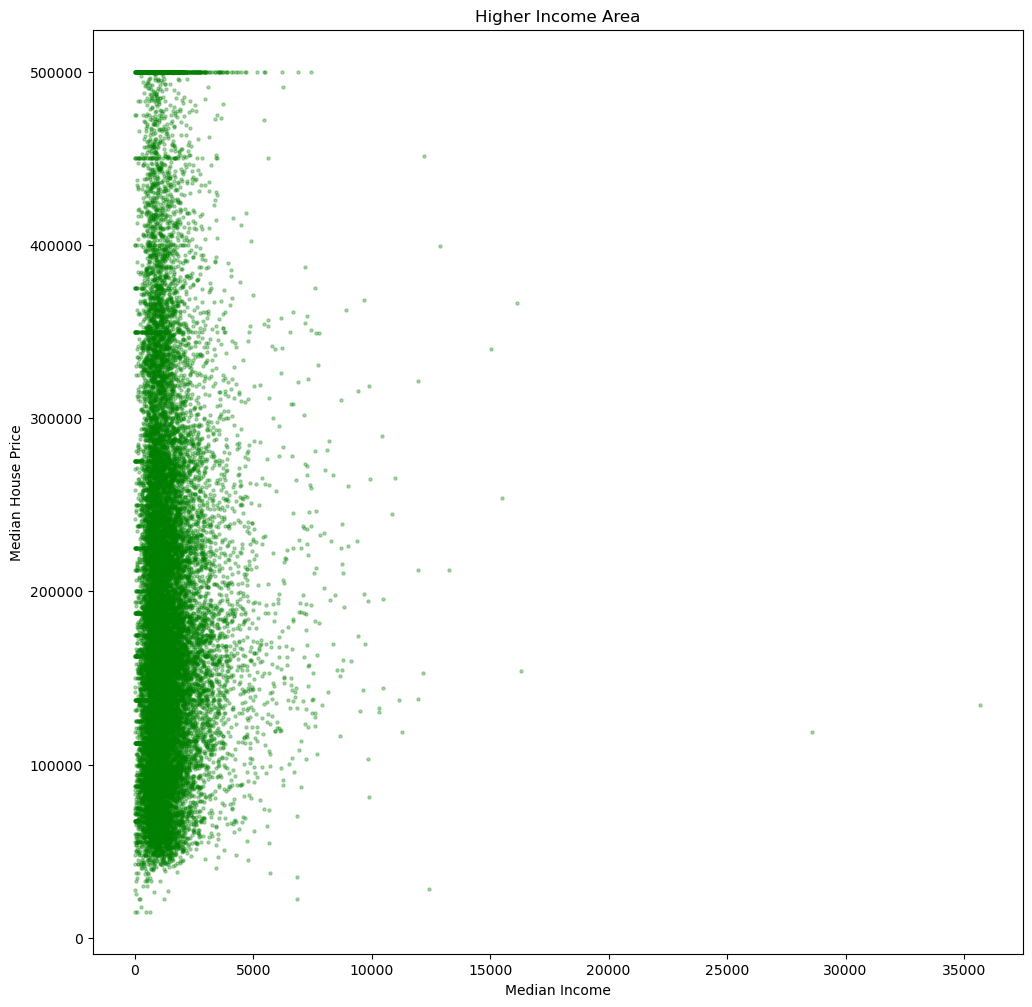

In [5]:
## Visulaization: Income VS Median House Price
feature = 'population'
plt.figure(figsize= (12,12))
plt.scatter(df[feature],df['median_house_value'], alpha=0.3, color = 'green', s=5)
plt.xlabel ("Median Income")
plt.ylabel("Median House Price")
plt.title("Higher Income Area")
plt.show()

In [51]:

## train/ test Split
X = df_encoded.drop ('median_house_value', axis =1)
Y = df_encoded['median_house_value']
X_train, X_test,Y_train, Y_test = train_test_split(X,Y,test_size = 0.2 , random_state = 42 )




print(f"Testing sample: {X_test.shape[0]}")
print(f"Trainning sample: {X_train.shape[0]}")

Testing sample: 4128
Trainning sample: 16512


In [52]:
## Model Trainning

model = LinearRegression()
model.fit(X_train,Y_train)

print("Model Trained!")
print(f"\n Inetercept:{model.intercept_:.4f}")

Model Trained!

 Inetercept:-2275547.3817


In [53]:
print(f"Model Intercept:\n{model.intercept_}")

print(f"Coefficients:\n {model.coef_}")

Model Intercept:
-2275547.3817167385
Coefficients:
 [-2.68382734e+04 -2.54683520e+04  1.10218508e+03 -6.02150567e+00
  1.02789395e+02 -3.81729064e+01  4.82527528e+01  3.94739752e+04
 -3.97866562e+04  1.36125073e+05 -5.13664222e+03  3.43114007e+03]


In [54]:
corr_target = (
    corr_matrix["median_house_value"]
    .sort_values(ascending=False)
)

print(f"Correlations: \n {corr_target}")

Correlations: 
 median_house_value            1.000000
median_income                 0.688075
ocean_proximity_NEAR BAY      0.160284
ocean_proximity_NEAR OCEAN    0.141862
total_rooms                   0.134153
housing_median_age            0.105623
households                    0.065843
total_bedrooms                0.049457
ocean_proximity_ISLAND        0.023416
population                   -0.024650
longitude                    -0.045967
latitude                     -0.144160
ocean_proximity_INLAND       -0.484859
Name: median_house_value, dtype: float64


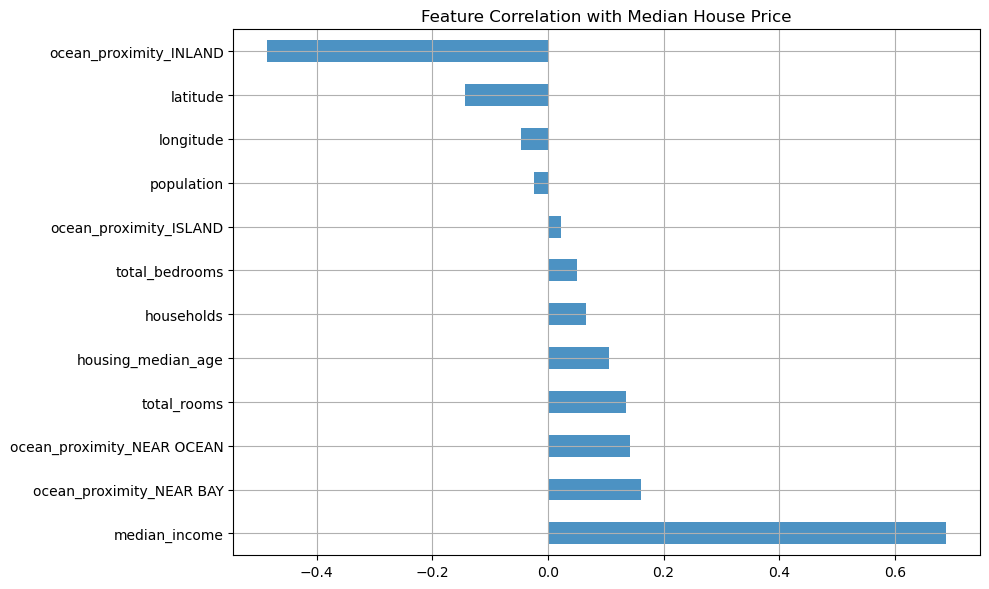

In [55]:
# Correlations
corr_target.drop("median_house_value").plot(
    kind="barh",
    alpha = 0.8 ,
    grid = True,
    figsize=(10,6))

plt.title("Feature Correlation with Median House Price")
plt.tight_layout()
plt.savefig(
    "../images/target_correlations.png",
    dpi=300
)
plt.show()

In [56]:
import sklearn
print(sklearn.__version__)

1.6.1


In [57]:
from sklearn.metrics import mean_squared_error
help(mean_squared_error)

Help on function mean_squared_error in module sklearn.metrics._regression:

mean_squared_error(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average'
)
    Mean squared error regression loss.

    Read more in the :ref:`User Guide <mean_squared_error>`.

    Parameters
    ----------
    y_true : array-like of shape (n_samples,) or (n_samples, n_outputs)
        Ground truth (correct) target values.

    y_pred : array-like of shape (n_samples,) or (n_samples, n_outputs)
        Estimated target values.

    sample_weight : array-like of shape (n_samples,), default=None
        Sample weights.

    multioutput : {'raw_values', 'uniform_average'} or array-like of shape             (n_outputs,), default='uniform_average'
        Defines aggregating of multiple output values.
        Array-like value defines weights used to average errors.

        'raw_values' :
            Returns a full set of errors in case of multioutput input.

        'uniform_ave

In [58]:
import inspect
print(inspect.signature(mean_squared_error))

(y_true, y_pred, *, sample_weight=None, multioutput='uniform_average')


In [59]:
## Interpret,Weights
weights = pd.DataFrame({
    'Feature' : X.columns,
    'Weight'  : model.coef_
}).sort_values('Weight',ascending = False)

print(weights)

                       Feature         Weight
9       ocean_proximity_ISLAND  136125.072615
7                median_income   39473.975175
11  ocean_proximity_NEAR OCEAN    3431.140073
2           housing_median_age    1102.185084
4               total_bedrooms     102.789395
6                   households      48.252753
3                  total_rooms      -6.021506
5                   population     -38.172906
10    ocean_proximity_NEAR BAY   -5136.642217
1                     latitude  -25468.352050
0                    longitude  -26838.273372
8       ocean_proximity_INLAND  -39786.656161


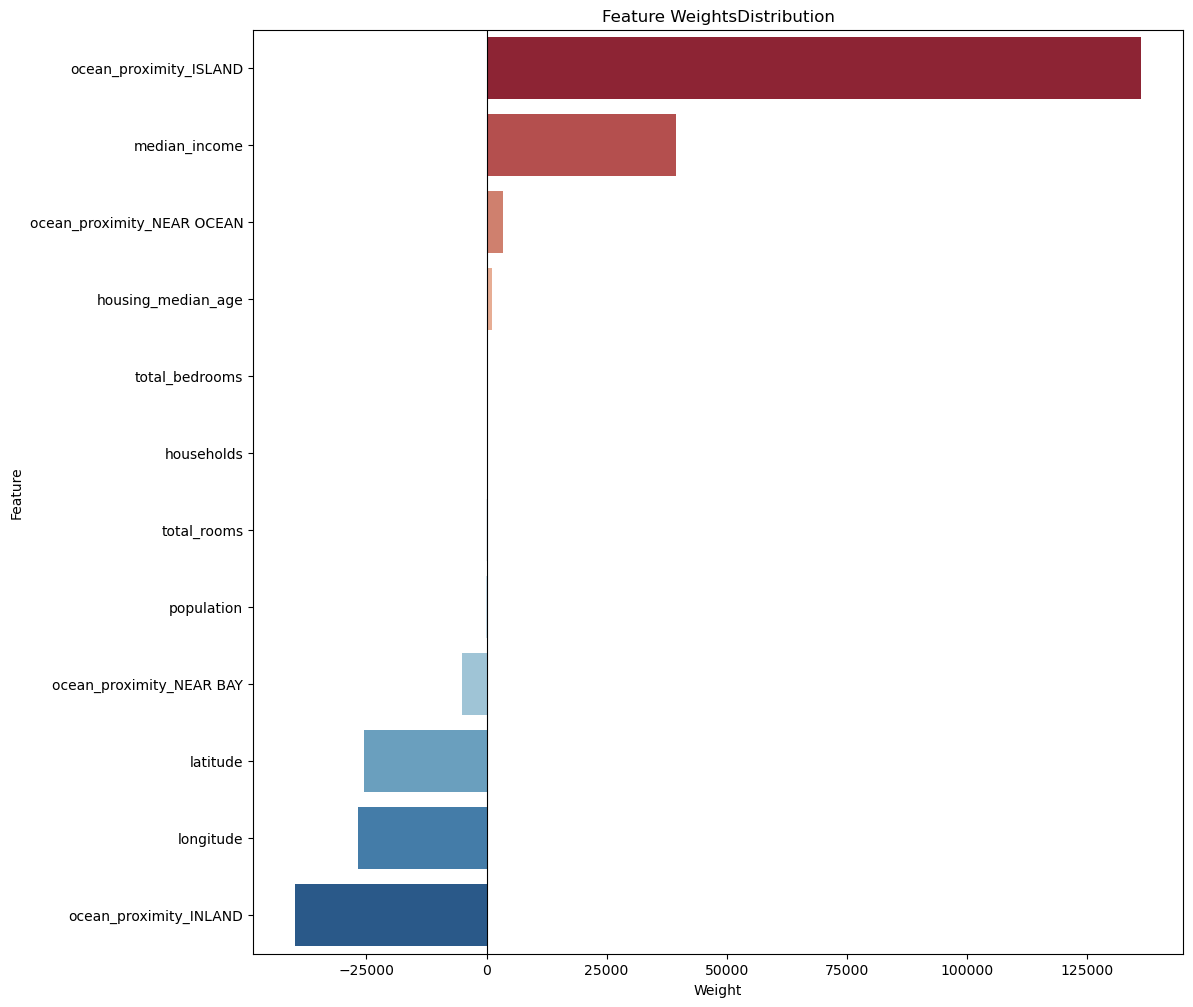

In [60]:
# Weight Distribution
plt.figure(figsize=(12, 12))
sns.barplot(data=weights, x='Weight', y='Feature', hue='Feature', legend=False, palette='RdBu')
plt.title('Feature WeightsDistribution')
plt.axvline(0, color='black', linewidth=0.8)
plt.show()

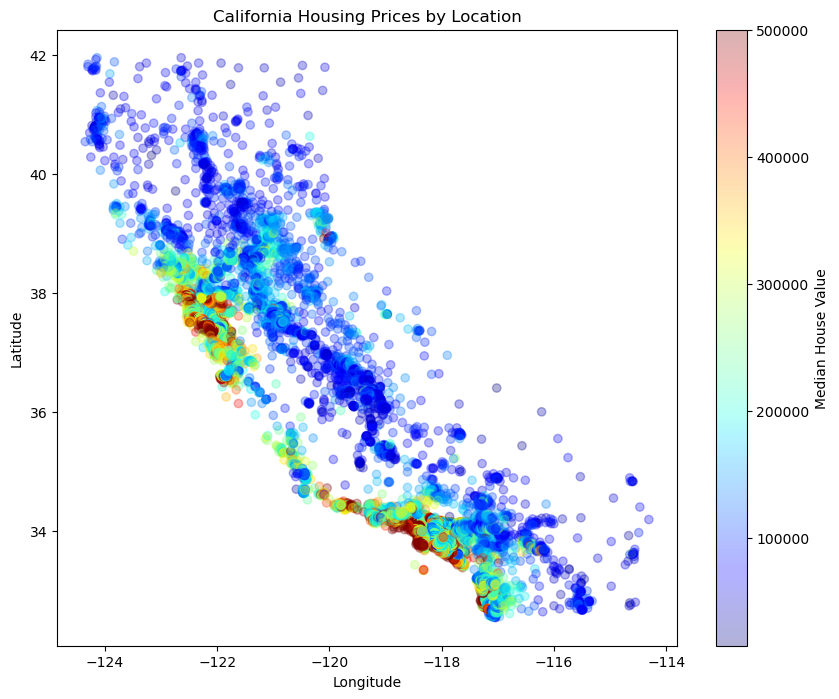

In [61]:
plt.figure(figsize=(10,8))

plt.scatter(
    df_encoded["longitude"],
    df_encoded["latitude"],
    alpha=0.3,
    c=df_encoded["median_house_value"],
    cmap="jet"
)

plt.colorbar(
    label="Median House Value"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.title(
    "California Housing Prices by Location"
)

plt.savefig(
    "../images/geographical_distribution.png",
    dpi=300
)

plt.show()

### Model Evaluation : R-Squared,RMSE, Residual Plot

In [70]:
# R Squared-Score, RMSE
Y_pred = model.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

RMSE: 70060.5218
R² Score: 0.6254


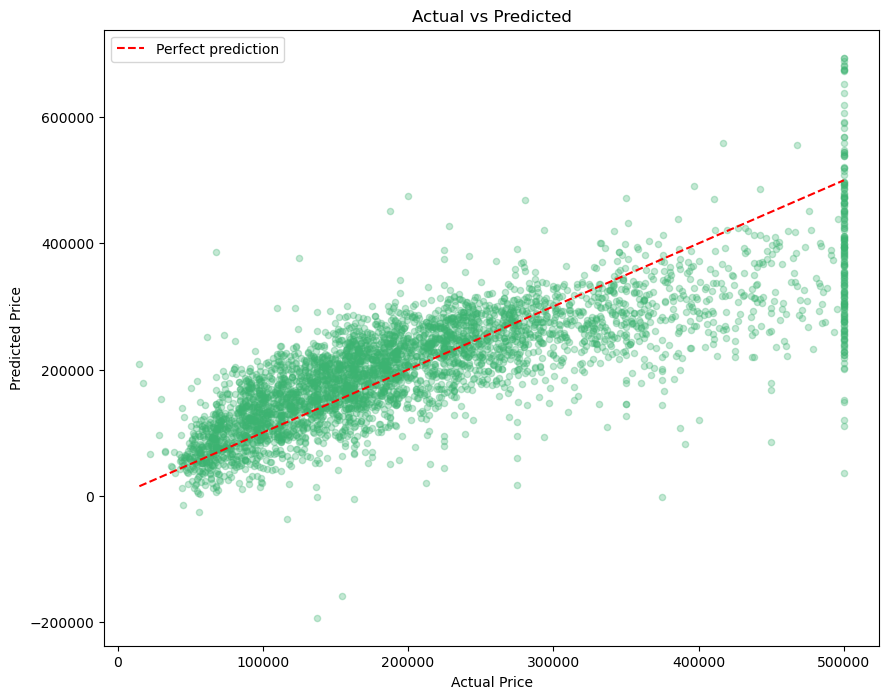

In [63]:
# Actual VS Predicted Model
plt.figure(figsize=(10, 8))
plt.scatter(Y_test, Y_pred, alpha=0.3, color='mediumseagreen', s=20)
plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         'r--', linewidth=1.5, label='Perfect prediction')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

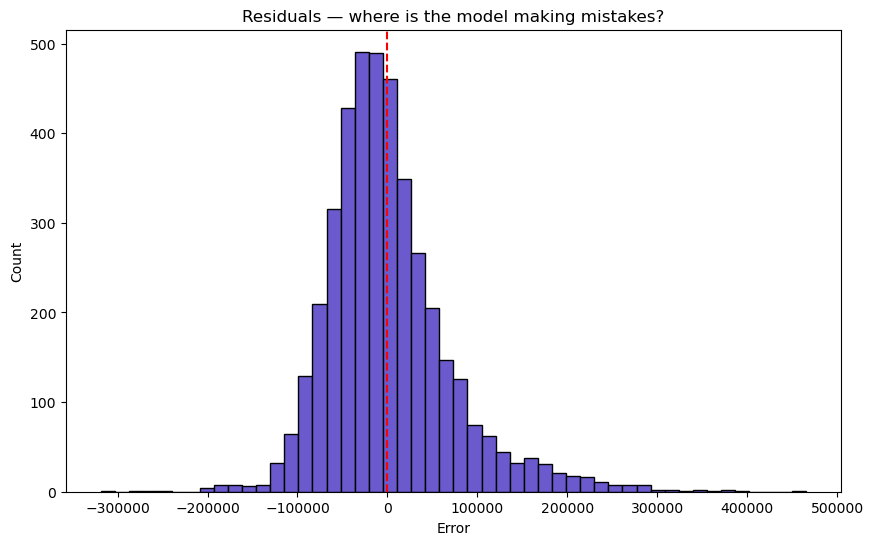

In [64]:
# Residual Plot (non-normalized)
residuals = Y_test - Y_pred

plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, color='slateblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals — where is the model making mistakes?')
plt.xlabel('Error')
plt.ylabel('Count')
plt.show()

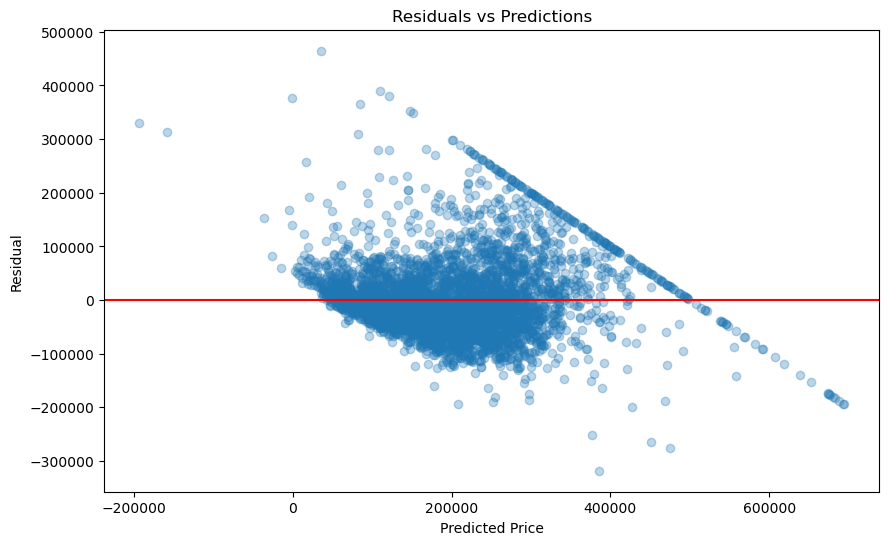

In [65]:
plt.figure(figsize=(10,6))
plt.scatter(
    Y_pred,
    residuals,
    alpha=0.3
)
plt.axhline(
    y=0,
    color='red'
)
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residuals vs Predictions")
plt.show()

## Califonia Housing Data Set : Predicting the price of the house by Decision Tree Regressior


In [76]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
import pandas as pd

# Decision Tree Model

dt_model = DecisionTreeRegressor(random_state =42)

dt_model.fit(X_train,Y_train)
Y_pred_dt = dt_model.predict(X_test)


# Evaluate Model
dt_r2 = r2_score(Y_test,Y_pred_dt)
dt_rmse = np.sqrt(
    mean_squared_error(Y_test, Y_pred_dt)
)

print(f"Decision Tree R_squared : {dt_r2:.4f}")
print(f"Decision Tree RMSE : {dt_rmse:.4f}")


Decision Tree R_squared : 0.6287
Decision Tree RMSE : 69755.7800


                     Model  R_Squared          RMSE
0        Linear Regression   0.625424  70060.521845
1  Decision Tree Regressor   0.628676  69755.779954


In [79]:
# Overfitted model on data .
print("Training R²:", dt_model.score(X_train, Y_train))
print("Testing R² :", dt_model.score(X_test, Y_test))

Training R²: 1.0
Testing R² : 0.6286755571919975


In [82]:
## Califonia Housing Data Set : Predicting the price of the house by Decision Tree Regressior
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor (
    n_estimators = 100,                # ----Build 100 decision trees
    random_state = 42,                 # ---- Makes results reproducible
    n_jobs = -1                        # ---- Uses all available CPU cores for faster training
    
)

In [85]:
rf_model.fit(X_train, Y_train)
Y_pred_rf = rf_model.predict(X_test)

# Evaluation

rf_r2 = r2_score(Y_test, Y_pred_rf)
rf_rmse = np.sqrt (
    mean_squared_error(Y_test,Y_pred_rf)
)
print(f"Random Forest R_Squared Score:{rf_r2:.4f}")
print(f"Random Forest RMSE:{rf_rmse:.4f}")

Random Forest R_Squared Score:0.8165
Random Forest RMSE:49038.2093


In [90]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree Regressor",
        "Random Forest Regressor"
    ],
    "R_Squared":[
        r2,
        dt_r2,
        rf_r2
    ],
    "RMSE":[
        rmse,
        dt_rmse,
        rf_rmse
    ]
})

print(comparison)

                     Model  R_Squared          RMSE
0        Linear Regression   0.817958  48841.569314
1  Decision Tree Regressor   0.628676  69755.779954
2  Random Forest Regressor   0.816489  49038.209338


### Random Forest regressor selected as the Model for Hyper Parameter Tuning

In the case GridSearchCV use to search for better values on,
 * n_estimators
 * max_depth
 * min_samples_split
 * min_samples_leaf

In [88]:
from sklearn.model_selection import GridSearchCV
param_grid = param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}


grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, Y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score: 0.8193965242443136


In [89]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

r2 = r2_score(Y_test, y_pred)
rmse = np.sqrt(mean_squared_error(Y_test, y_pred))

print("Test R² :", r2)
print("Test RMSE:", rmse)

Test R² : 0.8179576809516741
Test RMSE: 48841.56931351823


In [19]:
pip install joblib


Note: you may need to restart the kernel to use updated packages.


In [23]:
import joblib
joblib.dump(model, '../models/linear_regression.pkl')


['../models/linear_regression.pkl']

In [24]:
%whos

Variable             Type                Data/Info
--------------------------------------------------
LinearRegression     ABCMeta             <class 'sklearn.linear_mo<...>._base.LinearRegression'>
SimpleImputer        type                <class 'sklearn.impute._base.SimpleImputer'>
X                    DataFrame                  longitude  latitud<...>[20640 rows x 12 columns]
X_test               DataFrame                  longitude  latitud<...>n[4128 rows x 12 columns]
X_train              DataFrame                  longitude  latitud<...>[16512 rows x 12 columns]
Y                    Series              0        452600.0\n1     <...>th: 20640, dtype: float64
Y_pred               ndarray             4128: 4128 elems, type `float64`, 33024 bytes
Y_test               Series              20046     47700.0\n3024  <...>gth: 4128, dtype: float64
Y_trian              Series              14196    103000.0\n8267  <...>th: 16512, dtype: float64
corr_matrix          DataFrame                

In [25]:
type(model)

sklearn.linear_model._base.LinearRegression

In [26]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
